In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

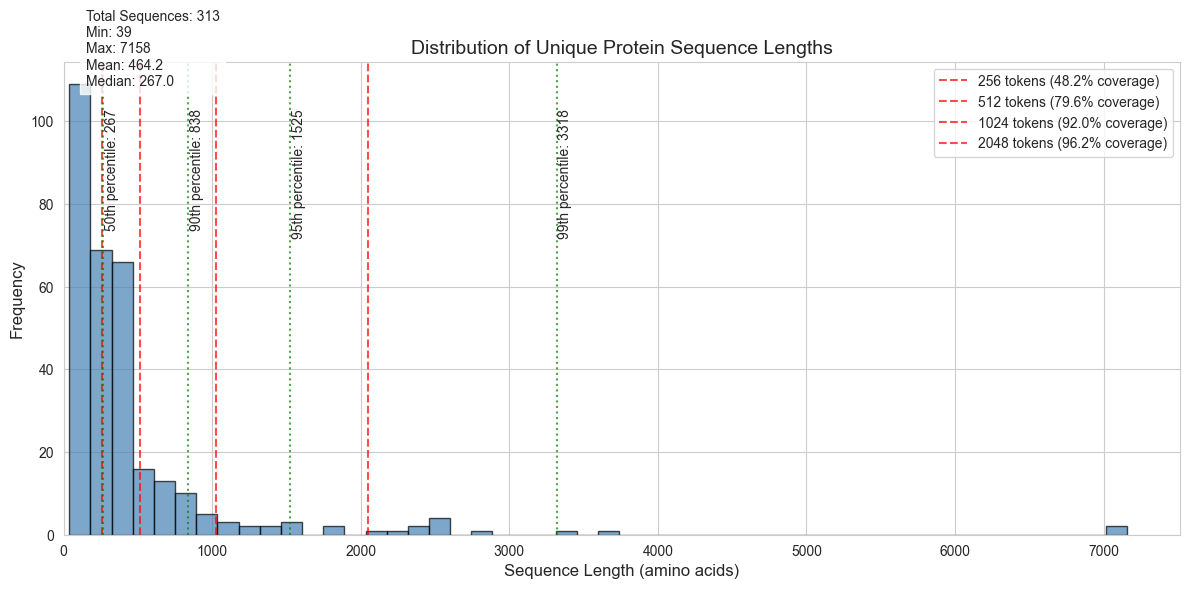

In [23]:
dataset = "protein_dataset.tsv"

def plot_sequence_length_distribution(file_path):
    sns.set_style("whitegrid")
    plt.figure(figsize=(12, 6))

    df = pd.read_csv(file_path, sep="\t")
    unique_sequences = df['Protein_Sequence'].unique()
    sequence_lengths = [len(seq) for seq in unique_sequences]

    plt.hist(sequence_lengths, bins=50, alpha=0.7, color="steelblue", edgecolor="black")

    common_lengths = [256, 512, 1024, 2048]
    for length in common_lengths:
        plt.axvline(
            x=length,
            color="red",
            linestyle="--",
            alpha=0.7,
            label=f"{length} tokens" if length == common_lengths[0] else f"{length}",
        )
        
    percentiles = [50, 90, 95, 99]
    percentile_values = np.percentile(sequence_lengths, percentiles)

    for p, val in zip(percentiles, percentile_values):
        plt.axvline(x=val, color="green", linestyle=":", alpha=0.7)
        plt.text(
            val + 10,
            plt.gca().get_ylim()[1] * 0.9,
            f"{p}th percentile: {int(val)}",
            rotation=90,
            verticalalignment="top",
        )

    coverage = {}
    for length in common_lengths:
        coverage[length] = (np.array(sequence_lengths) <= length).mean() * 100

    coverage_labels = [
        f"{length} tokens ({coverage[length]:.1f}% coverage)" for length in common_lengths
    ]
    plt.legend(coverage_labels, loc="upper right")

    plt.xlabel("Sequence Length (amino acids)", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.title("Distribution of Unique Protein Sequence Lengths", fontsize=14)

    stats_text = (
        f"Total Sequences: {len(unique_sequences)}\n"
        f"Min: {min(sequence_lengths)}\n"
        f"Max: {max(sequence_lengths)}\n"
        f"Mean: {np.mean(sequence_lengths):.1f}\n"
        f"Median: {np.median(sequence_lengths)}"
    )
    plt.text(
        0.02,
        0.95,
        stats_text,
        transform=plt.gca().transAxes,
        bbox=dict(facecolor="white", alpha=0.8),
    )

    plt.xlim(left=0)
    plt.tight_layout()
    plt.show()

plot_sequence_length_distribution(dataset)

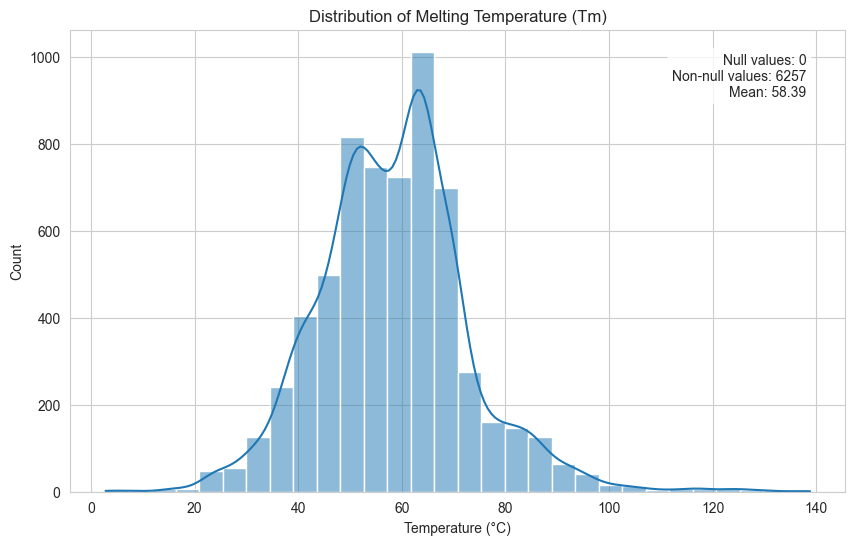

In [ ]:
df = pd.read_csv("2temp.tsv", sep='\t')

df['Tm_(C)'] = pd.to_numeric(df['Tm_(C)'].str.extract(r'([\d.-]+)')[0], errors='coerce')

null_count = df['Tm_(C)'].isnull().sum()
non_null_count = df['Tm_(C)'].notnull().sum()

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Tm_(C)', bins=30, kde=True)
plt.title('Distribution of Melting Temperature (Tm)')
plt.xlabel('Melting Temperature (°C)')
plt.ylabel('Count')

info_text = f'Null values: {null_count}\nNon-null values: {non_null_count}\nMean: {df["Tm_(C)"].mean():.2f}'
plt.text(0.95, 0.95, info_text,
         transform=plt.gca().transAxes,
         verticalalignment='top',
         horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.show()